# Comparing patpy sample representations for influenza vaccine-response prediction

In this tutorial we show a `patpy` workflow for a sample-level prediction task using PBMC single-cell RNA-seq data.

The task is inspired by PULSAR: can baseline immune profiles measured on influenza vaccination day 0 tell us something about day-7 vaccine response?

We will:
1. make one vaccine-response label per donor per season
2. load only baseline day-0 PBMC cells with available labels
3. build several sample representations
4. compare how well those representations predict the vaccine-response label

We compare four approaches:

- cell-group composition
- pseudobulk expression
- GloScope
- MixMIL

## Data

We use two young, CMV-positive Sound Life PBMC scRNA-seq AnnData files: one female cohort and one male cohort. The response labels are not stored directly in the AnnData objects. They are taken from another MSD HAI metadata file `sound-life_flu_hai_single.csv`.

The response label is defined at donor-season level using `subject.subjectGuid` and `vaccine_year`.

#### Imports


In [18]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from sklearn.metrics import classification_report

import patpy

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

patpy.__version__

'0.15.4'

#### Input files
To keep the tutorial lightweight, we only use a cohort of the full dataset, which contains young CMV-positive Sound Life samples of both gender. We will load both subsequently, process them and then concatenate both.

The keys are the columns that we will use throughout the notebook.

We use `AIFI_L2` as the cell-group annotation. It is an intermediate annotation level: more informative than `AIFI_L1`, but less sparse than `AIFI_L3`.

In [2]:
from pathlib import Path

DATA_DIR = Path.home() / "Downloads"

adata_paths = [
    DATA_DIR / "SoundLife_YoungAdult_Male_CMVpos.h5ad",
    DATA_DIR / "SoundLife_YoungAdult_Female_CMVpos.h5ad",
]

hai_path = DATA_DIR / "sound-life_flu_hai_single.csv"

sample_key = "sample.sampleKitGuid"
donor_key = "subject.subjectGuid"
visit_key = "sample.visitName"
season_key = "vaccine_year"
cell_group_key = "AIFI_L2"
label_key = "vaccine_response"

baseline_visits = ["Flu Year 1 Day 0", "Flu Year 2 Day 0"]

## Construct vaccine-response labels

The HAI metadata contains antigen-level measurements. We first create strain-level response labels and then aggregate them to donor-season labels.

For each selected antigen, response is defined as:

`msd.percentNormInhibition > 30`

A donor-season is labeled as `high_response` if ANY selected vaccine strain passes this threshold.

First we load the HAI metadata

In [3]:
hai = pd.read_csv(hai_path)

# lets rename the vaccine column
hai = hai.rename(columns={"vaccine.year": "vaccine_year"})

print("HAI shape:", hai.shape)
hai.head()

HAI shape: (9140, 26)


,cohort.cohortGuid,subject.subjectGuid,subject.birthYear,subject.ageAtFirstDraw,subject.ageGroup,subject.biologicalSex,subject.race,subject.ethnicity,subject.cmv,sample.sampleKitGuid,...,msd.batchID,msd.plateID,msd.antigenName,msd.antigenSubtype,msd.antigenFullName,msd.sampleDilution,msd.signalNormMean,msd.signalNormPercentCV,msd.blankNormMean,msd.percentNormInhibition
0,BR1,BR1044,1994,26,Young Adult,Male,Caucasian,Non-Hispanic origin,Positive,KT00511,...,PLAN-00144-5,2BMACAT013_Batch5_Plate15,A/Kansas,H3N2,A/Kansas/14/2017 (H3N2)-like virus,5000,10268.0,4.518894,15833.5,35.150156
1,BR1,BR1006,1988,31,Young Adult,Male,Caucasian,Non-Hispanic origin,Negative,KT00017,...,PLAN-00144-1,2BMACA6053_Batch1_Plate3,A/Cambodia,H3N2,A/Cambodia/e0826360/2020 (H3N2)-like virus,5000,5412.5,3.427252,6905.0,21.614772
2,BR2,BR2015,1964,56,Older Adult,Female,Caucasian,Non-Hispanic origin,Negative,KT00629,...,EXP-01072,Plate_2BMACAP012,B/Washington,Victoria,B/Washington/02/2019-like virus (B/Victoria li...,5000,243071.5,9.618363,598706.0,59.400524
3,BR1,BR1028,1989,31,Young Adult,Female,Caucasian,Non-Hispanic origin,Negative,KT02541,...,PLAN-00144-4,2BMACA2024_Batch4_Plate11,B/Washington,Victoria,B/Washington/02/2019-like virus (B/Victoria li...,5000,418953.0,20.394889,576071.0,27.274069
4,BR2,BR2008,1964,56,Older Adult,Female,Caucasian,Non-Hispanic origin,Negative,KT00619,...,PLAN-00144-1,2BMACA6053_Batch1_Plate3,B/Washington,Victoria,B/Washington/02/2019-like virus (B/Victoria li...,5000,361300.5,10.631732,658534.5,45.135676


In [4]:
day7_visits = ["Flu Year 1 Day 7", "Flu Year 2 Day 7"]

strains_by_season = {
    "2020-2021": ["A/Guangdong", "A/Phuket", "B/Washington"],
    "2021-2022": ["A/Cambodia", "A/Phuket", "B/Washington"],
}

selected = []

for season, strains in strains_by_season.items():
    # select only the strains of the respective season and only the 7 day visit samples.
    mask = ((hai["vaccine_year"] == season) & (hai["sample.visitName"].isin(day7_visits)) & (hai["msd.antigenName"].isin(strains)))
    selected.append(hai.loc[mask].copy())

hai_selected = pd.concat(selected, axis=0)

# group and average across multiples per strain
strain_response = (
    hai_selected.groupby(["subject.subjectGuid", "vaccine_year", "msd.antigenName"], as_index=False)["msd.percentNormInhibition"].mean()
    )
# apply response threshold strainwise
strain_response["responded_to_strain"] = (strain_response["msd.percentNormInhibition"] > 30)
# now aggregate the strains to get one response label per donor per season
response = (
    strain_response
    .groupby([donor_key, season_key], as_index=False)
    .agg(vaccine_response=("responded_to_strain", "any")
    )
)

# make class lable readable categories
response[label_key] = response[label_key].map({False: "low_response", True: "high_response"}).astype("category")

display(response.groupby("vaccine_year")[label_key].value_counts())

response


vaccine_year  vaccine_response
2020-2021     high_response       72
              low_response        18
2021-2022     high_response       42
              low_response        26
Name: count, dtype: int64

,subject.subjectGuid,vaccine_year,vaccine_response
0,BR1002,2020-2021,high_response
1,BR1003,2020-2021,high_response
2,BR1004,2020-2021,high_response
3,BR1005,2020-2021,high_response
4,BR1006,2020-2021,low_response
...,...,...,...
153,BR2051,2021-2022,high_response
154,BR2052,2020-2021,high_response
155,BR2052,2021-2022,low_response
156,BR2053,2020-2021,low_response


## Load labeled baseline cells

The full AnnData files can be large. To keep memory use low, we process the two cohort files one at a time. We load them in backed mode, check `.obs` for cells we actually need and then only load those. Then we concatenate everything to one adata object.


In [5]:
def load_cells(path, response):
    # backed reads metadata but keeps the expression matrix on disk
    adata_backed = sc.read_h5ad(path, backed="r")
    # take cell metadata to decide which cell to load
    obs = adata_backed.obs.copy()

    # filter for baseline samples and add response label
    # the response table is at donor-season level, so we join those
    baseline_samples = (
        obs.loc[
            obs[visit_key].isin(baseline_visits),
            [sample_key, donor_key, season_key, visit_key],
        ]
        .drop_duplicates()
        .merge(response, on=[donor_key, season_key], how="inner")
    )

    keep_cells = obs[sample_key].isin(baseline_samples[sample_key]).values

    # only load subset
    adata_subset = adata_backed[keep_cells, :].to_memory()
    adata_backed.file.close()
    
    # add labels
    label_map = baseline_samples.set_index(sample_key)[label_key]
    adata_subset.obs[label_key] = (
        adata_subset.obs[sample_key].map(label_map).astype("category")
    )
    # add from which cohort the cell came
    adata_subset.obs["source_file"] = path.stem

    return adata_subset


adata = ad.concat(
    [load_cells(path, response) for path in adata_paths],
    join="inner",
    index_unique="-",
)

adata

AnnData object with n_obs × n_vars = 421439 × 33538
    obs: 'barcodes', 'original_barcodes', 'cell_name', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_genes', 'n_reads', 'n_umis', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'predicted_AIFI_L1', 'AIFI_L1_score', 'AIFI_L1', 'predicted_AIFI_L2', 'AIFI_L2_score', 'AIFI_L2', 'predicted_AIFI_L3', 'AIFI_L3_score', 'AIFI_L3', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.cmv', 'subject.bmi', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'subject.ageAtFirstDraw', 'sample.visitName', 'sample.drawYear', 'sample.subjectAgeAtDraw', 'specimen.specimenGuid', 'pipeline.fileGuid', 'subject.ageGroup', 'vaccine_year', 'vaccine_response', 'source_file'
    obsm: 'X_umap'

In [6]:
print(f"{adata.n_obs:,} cells")
print(f"{adata.n_vars:,} genes")
print(f"{adata.obs[sample_key].nunique()} labeled baseline samples")

adata.obs[[sample_key, season_key, label_key]].drop_duplicates()[label_key].value_counts()

421,439 cells
33,538 genes
26 labeled baseline samples


vaccine_response
high_response    20
low_response      6
Name: count, dtype: int64

## Preprocessing

We keep preprocessing minimal. 

We remove samples with too few cells using `patpy.pp.filter_small_samples`. If memory is still limiting, `patpy.pp.subsample` can be enabled to keep at least 500 cells per sample while reducing total cell count.

Then we create sample level metadata that is indexed by `sample_key`. 

In [7]:
adata = patpy.pp.filter_small_samples(
    adata,
    sample_key=sample_key,
    sample_size_threshold=250,
)

# Optional if you need to save memory:
# adata = patpy.pp.subsample(
#     adata,
#     obs_category_col=sample_key,
#     min_samples_per_category=500,
#     fraction=0.5,
# )

sample_metadata = patpy.pp.extract_metadata(
    adata,
    sample_key=sample_key,
    columns=[label_key, donor_key, season_key, visit_key],
)

sample_metadata[label_key].value_counts()

0 samples removed: 


vaccine_response
high_response    20
low_response      6
Name: count, dtype: int64

No samples were removed, so we keep all baseline samples.

## Cell-level feature space for GloScope and MixMIL

GloScope and MixMIL operate on cell-level features. To give both methods a compact cell representation, we normalize, log-transforme, and subset for highly variable genes. Then we compute PCA.

So now we have `adata_features`, a feature-engineered copy for PCA-based methods.

In [8]:
adata_features = adata.copy()

sc.pp.normalize_total(adata_features, target_sum=1e4)
sc.pp.log1p(adata_features)
sc.pp.highly_variable_genes(
    adata_features,
    n_top_genes=2000,
    subset=True,
)
sc.pp.pca(
    adata_features,
    n_comps=50,
    random_state=RANDOM_STATE,
)

##  Evaluation of sample representations

For composition, pseudobulk, and GloScope, patpy produces a sample-by-sample distance matrix.
With this, we can evaluate whether samples that are close int that space tend to share the same response label to vaccination.

In [9]:
def evaluate_distances(method, distances):
    """
    Small eval helper that can be reused.
    """

    # align the labels to the sample order of the representation object
    target = sample_metadata.loc[method.samples, label_key]
    # now apply the evaluation
    return patpy.tl.evaluate_representation(
        distances=distances.copy(),
        target=target,
        method="knn",
        task="classification",
        n_neighbors=3,
    )

## Cell-group composition

Cell-group composition tests whether we can find some signal of the vaccine response in the differnt abundances of cell groups. This representation ignores gene expression and uses only celltype proportions.

In [10]:
composition = patpy.tl.CellGroupComposition(
    sample_key=sample_key,
    cell_group_key=cell_group_key,
)

composition.prepare_anndata(adata)

# calculate pairwise distances between sample composition vectors
composition_distances = composition.calculate_distance_matrix(
    force=True,
    dist="euclidean",
)

# check if nearest neigbour in composition space reflects response lables
composition_result = evaluate_distances(
    method=composition,
    distances=composition_distances,
)

composition_result

{'score': np.float64(0.1333333333333333),
 'metric': 'f1_macro_calibrated',
 'n_unique': 2,
 'n_observations': 26,
 'method': 'knn'}

## Pseudobulk

Pseudobulk aggregates gene expression across cells within each sample.

Because counts are in `adata.X`, we use `layer=None`.

In [11]:
pseudobulk = patpy.tl.Pseudobulk(
    sample_key=sample_key,
    cell_group_key=cell_group_key,
    layer=None, 
)

pseudobulk.prepare_anndata(adata)

# here we use cosine distance not euclidian because the magnitures can differ severely
pseudobulk_distances = pseudobulk.calculate_distance_matrix(
    force=True,
    aggregate="sum",
    dist="cosine",
)

pseudobulk_result = evaluate_distances(
    method=pseudobulk,
    distances=pseudobulk_distances,
)

pseudobulk_result

/Users/lbrem/projects/patpy/src/patpy/tl/sample_representation.py:1092: UserWarning: Using data from adata.X
  data = self._get_data()


{'score': np.float64(0.2571428571428571),
 'metric': 'f1_macro_calibrated',
 'n_unique': 2,
 'n_observations': 26,
 'method': 'knn'}

## GloScope

GloScope compares samples as distribution of cells in a cell-level feature space.
Here we use PCA features in `adata_features.obsm["X_pca"]` and compute a divergence matrix.

For more information on how to use GloScope, refer to `sources_of_variation_with_gloscope.ipynb`.

In [12]:
gloscope = patpy.tl.GloScope_py(
    sample_key=sample_key,
    layer="X_pca",
    k=25, # this is not the sample kNN parameter, but the cell-level neighborhood parameter
    use_gpu=False  # set True if CUDA is available to accelerate gloscope
)

gloscope.prepare_anndata(adata_features)

# calculate divergence
gloscope_distances = gloscope.calculate_distance_matrix(force=True)

gloscope_result = evaluate_distances(
    method=gloscope,
    distances=gloscope_distances
)

gloscope_result

/Users/lbrem/projects/patpy/src/patpy/tl/sample_representation.py:1907: UserWarning: Using data from adata.obsm['X_pca']
  data = self._get_data()


{'score': np.float64(0.19290465631929044),
 'metric': 'f1_macro_calibrated',
 'n_unique': 2,
 'n_observations': 26,
 'method': 'knn'}

## MixMIL

We now run MixMIL as a supervised sample-level method.

MixMIL treats each sample as a bag of cells and learns to predict sample-level response labels. 
We use the same PCA cell features as GloScope

For more information on how to use MixMIL with patpy, see `supervised_methods_example.ipynb`

In [13]:
adata_mixmil = adata_features

Initialize MixMIL. We use `classification` because the vaccine-response label is binary.

In [14]:
mixmil = patpy.tl.supervised.MixMIL(
    sample_key=sample_key,
    label_keys=[label_key],
    tasks=["classification"],
    layer="X_pca",
    n_epochs=100,
)

Train the MixMIL model.

In [15]:
mixmil.prepare_anndata(adata_mixmil)

/Users/lbrem/Library/Application Support/hatch/env/virtual/patpy/nswK682A/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/lbrem/projects/patpy/src/patpy/tl/supervised.py:857: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)
Epoch: 100%|██████████| 100/100 [00:04<00:00, 23.30it/s]


We can inspect the training loss.

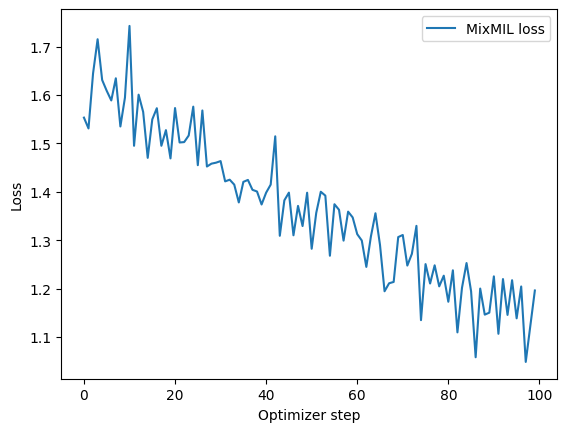

In [16]:
losses = [step["loss"] for step in mixmil.training_history]

plt.plot(losses, label="MixMIL loss")
plt.xlabel("Optimizer step")
plt.ylabel("Loss")
plt.legend()

We can now predict the vaccine-response label

In [19]:
mixmil_prediction = mixmil.predict(label_key)

y_true = sample_metadata.loc[mixmil_prediction.index, label_key]
print(classification_report(y_true, mixmil_prediction[f"{label_key}_pred"]))

               precision    recall  f1-score   support

high_response       1.00      0.65      0.79        20
 low_response       0.46      1.00      0.63         6

     accuracy                           0.73        26
    macro avg       0.73      0.82      0.71        26
 weighted avg       0.88      0.73      0.75        26



/Users/lbrem/projects/patpy/src/patpy/tl/supervised.py:857: UserWarning: Using data from adata.obsm['X_pca']
  X_sorted = self._get_data()[sort_idx].astype(self.dtype)


In [20]:
# convert predictions to the eval form used by other methods
mixmil_result = patpy.tl.evaluate_prediction(
    y_true=y_true,
    y_pred=mixmil_prediction[f"{label_key}_pred"],
    task="classification",
)
# add the same metadata fields for table represenation later
mixmil_result = {
    **mixmil_result,
    "n_unique": y_true.nunique(),
    "n_observations": len(y_true),
    "method": "supervised",
}

mixmil_result

{'score': np.float64(0.41945773524720886),
 'metric': 'f1_macro_calibrated',
 'n_unique': 2,
 'n_observations': 26,
 'method': 'supervised'}

## Compare methods
Let's compare all methods we used.

- For composition, pseudobulk, and GloScope, the score comes from kNN evaluation on sample distances.
- For MixMIL, the score comes directly from supervised prediction.

The score metric for classification is patpy's calibrated macro-F1 score

In [21]:
results = pd.DataFrame(
    [
        {
            "representation": "Cell-group composition",
            "evaluation": "kNN on sample distances",
            **composition_result,
        },
        {
            "representation": "Pseudobulk",
            "evaluation": "kNN on sample distances",
            **pseudobulk_result,
        },
        {
            "representation": "GloScope",
            "evaluation": "kNN on sample divergences",
            **gloscope_result,
        },
        {
            "representation": "MixMIL",
            "evaluation": "supervised prediction",
            **mixmil_result,
        },
    ]
)
results

,representation,evaluation,score,metric,n_unique,n_observations,method
0,Cell-group composition,kNN on sample distances,0.133333,f1_macro_calibrated,2,26,knn
1,Pseudobulk,kNN on sample distances,0.257143,f1_macro_calibrated,2,26,knn
2,GloScope,kNN on sample divergences,0.192905,f1_macro_calibrated,2,26,knn
3,MixMIL,supervised prediction,0.419458,f1_macro_calibrated,2,26,supervised


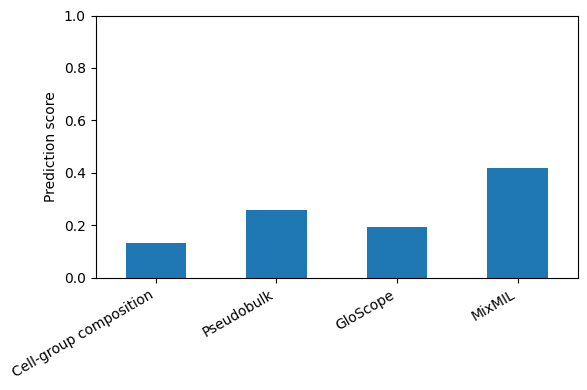

In [22]:
ax = results.plot.bar(
    x="representation",
    y="score",
    legend=False,
    ylim=(0, 1),
    figsize=(6, 4),
)

ax.set_ylabel("Prediction score")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()